In [6]:
import numpy as np
import scipy.signal as signal
import soundfile as sf

# サンプリング周波数
fs = 16000
duration = 1.0  # 秒

# 基本周波数（ピッチ）
f0 = 200  # Hz

# 有声音の励振信号（インパルス列）
t = np.arange(0, duration, 1/fs)
excitation = np.zeros_like(t)
excitation[::int(fs/f0)] = 1.0

# フォルマント周波数と帯域幅（母音 "a" の例，参考値）
formants = [
    (730, 80),   # F1
    (1090, 90),  # F2
    (2440, 120)  # F3
]

def resonator(f, bw, fs):
    """フォルマント共振器フィルタ係数を計算"""
    r = np.exp(-np.pi * bw / fs)
    theta = 2 * np.pi * f / fs
    b = [1 - r]
    a = [1, -2 * r * np.cos(theta), r**2]
    return b, a

# フィルタ適用
y = excitation.copy()
for f, bw in formants:
    b, a = resonator(f, bw, fs)
    y = signal.lfilter(b, a, y)

# 正規化
y /= np.max(np.abs(y))

# 書き出し
sf.write("formant_a.wav", y, fs)
print("合成音を formant_a.wav に保存しました。")


合成音を formant_a.wav に保存しました。


In [1]:
import numpy as np
import scipy.signal as sig
import sounddevice as sd

# サンプリング周波数
fs = 16000
duration = 1.0  # 秒
t = np.linspace(0, duration, int(fs*duration), endpoint=False)

# 基本周波数 F0（声の高さ）
f0 = 120

# ---- 励振信号の定義 ----

# 1. 正弦波
exc_sine = np.sin(2*np.pi*f0*t)

# impulse
#excitation = np.zeros_like(t)
#excitation[::int(fs/f0)] = 1.0

# duty=50% rect
#excitation = (np.sin(2*np.pi*f0*t) > 0).astype(float)  # 矩形波的パルス


# 2. Rosenberg波
def rosenberg_pulse(N, Tp=0.4, Tn=0.16):
    """
    Rosenberg波形（1周期分）
    N : サンプル数（1周期）
    Tp : 開時間率 (開口上昇の長さ / 周期)
    Tn : 閉時間率 (閉口下降の長さ / 周期)
    """
    nT = np.arange(N) / N
    y = np.zeros(N)
    # 開口上昇 (0 <= t < Tp)
    idx = nT < Tp
    y[idx] = 0.5*(1 - np.cos(np.pi*nT[idx]/Tp))
    # 閉口下降 (Tp <= t < Tp+Tn)
    idx = (nT >= Tp) & (nT < Tp+Tn)
    y[idx] = np.cos(np.pi*(nT[idx]-Tp)/(2*Tn))
    return y

# Rosenberg波の周期パルス列
period = int(fs/f0)
pulse = rosenberg_pulse(period)
exc_rosen = np.tile(pulse, int(len(t)/period)+1)[:len(t)]

# ---- フォルマントフィルタ ----
# 例: 母音 /a/ の簡易モデル (周波数と帯域幅)
formants = [(730, 80), (1090, 90), (2440, 120)]  # F1, F2, F3

def formant_filter(x, fs, formants):
    y = x
    for f, bw in formants:
        r = np.exp(-np.pi*bw/fs)
        theta = 2*np.pi*f/fs
        b = [1-r]
        a = [1, -2*r*np.cos(theta), r**2]
        y = sig.lfilter(b, a, y)
    return y

# 音声合成
y_sine = formant_filter(exc_sine, fs, formants)
y_rosen = formant_filter(exc_rosen, fs, formants)

# 正規化
y_sine = y_sine / np.max(np.abs(y_sine))
y_rosen = y_rosen / np.max(np.abs(y_rosen))

print("正弦波励振 → 再生します")
sd.play(y_sine, fs)
sd.wait()

print("Rosenberg励振 → 再生します")
sd.play(y_rosen, fs)
sd.wait()


正弦波励振 → 再生します
Rosenberg励振 → 再生します


In [5]:
import numpy as np
import scipy.signal as sig
import sounddevice as sd

# サンプリング周波数
fs = 16000
duration = 1.0  # 1秒

t = np.linspace(0, duration, int(fs*duration), endpoint=False)
f0 = 120  # 基本周波数（声の高さ）

# ========== 励振信号 ==========
# 1. 有声音用パルス列
exc_voiced = np.zeros_like(t)
exc_voiced[::int(fs/f0)] = 1.0  # インパルス列

# 2. 無声音用ノイズ
exc_noise = np.random.randn(len(t))

# ========== フィルタ（フォルマント） ==========
# 母音 /a/ の簡易モデル
formants_a = [(730, 80), (1090, 90), (2440, 120)]

def formant_filter(x, fs, formants):
    y = x
    for f, bw in formants:
        r = np.exp(-np.pi*bw/fs)
        theta = 2*np.pi*f/fs
        b = [1-r]
        a = [1, -2*r*np.cos(theta), r**2]
        y = sig.lfilter(b, a, y)
    return y

# "a"（母音）: パルス励振 + aフォルマント
y_a = formant_filter(exc_voiced, fs, formants_a)

# "s"（子音）: ノイズ励振 + 高域フィルタ強調
# ここではハイパスで簡単に「s」らしさを作る
b, a = sig.butter(4, 2000/(fs/2), btype="highpass")
y_s = sig.lfilter(b, a, exc_noise)

# 正規化
y_a /= np.max(np.abs(y_a))
y_s /= np.max(np.abs(y_s))

# ========== "sa" の合成 ==========
# 前半0.3秒 = "s", 後半0.7秒 = "a"
sa = np.zeros_like(t)
split = int(0.1*fs)
sa[:split] = y_s[:split]
sa[split:] = y_a[split:]

sa /= np.max(np.abs(sa))

print("『sa』を再生します")
sd.play(sa, fs)
sd.wait()


『sa』を再生します


In [4]:
import numpy as np
import scipy.signal as sig
import sounddevice as sd

fs = 16000
f0 = 120  # 基本周波数
duration = 1.0
t = np.linspace(0, duration, int(fs*duration), endpoint=False)

# ========== 励振 ==========
# 有声音 → パルス列
exc_voiced = np.zeros_like(t)
exc_voiced[::int(fs/f0)] = 1.0

# 無声音 → ノイズ
exc_noise = np.random.randn(len(t))

# ========== 母音フォルマント ==========
formants = {
    "a": [(730, 80), (1090, 90), (2440, 120)],
    "i": [(270, 60), (2290, 90), (3010, 100)],
    "u": [(300, 60), (870, 80), (2240, 120)],
}

def formant_filter(x, fs, formants):
    y = x
    for f, bw in formants:
        r = np.exp(-np.pi*bw/fs)
        theta = 2*np.pi*f/fs
        b = [1-r]
        a = [1, -2*r*np.cos(theta), r**2]
        y = sig.lfilter(b, a, y)
    return y

# 母音合成
def synth_vowel(vowel, excitation):
    return formant_filter(excitation, fs, formants[vowel])

# ========== 子音合成 ==========
def synth_s():  # /s/
    b, a = sig.butter(4, 2000/(fs/2), "highpass")
    return sig.lfilter(b, a, exc_noise)

def synth_sh():  # /ʃ/
    b, a = sig.butter(4, [1500/(fs/2), 6000/(fs/2)], "bandpass")
    return sig.lfilter(b, a, exc_noise)

def synth_k():  # /k/（破裂音）
    # 短いノイズバーストを作る
    burst = np.zeros_like(t)
    burst[:int(0.05*fs)] = np.random.randn(int(0.05*fs))
    b, a = sig.butter(4, 1000/(fs/2), "highpass")
    return sig.lfilter(b, a, burst)

# ========== C+V 合成 ==========
def synth_cv(consonant_func, vowel, split=0.3):
    split_n = int(split*fs)
    # 子音
    c = consonant_func()
    # 母音
    v = synth_vowel(vowel, exc_voiced)
    # 時間で接続
    y = np.zeros_like(t)
    y[:split_n] = c[:split_n]
    y[split_n:] = v[split_n:]
    # 正規化
    y /= np.max(np.abs(y) + 1e-9)
    return y

# ========== 再生 ==========
print("『sa』を再生")
sd.play(synth_cv(synth_s, "a"))
sd.wait()

print("『sha』を再生")
sd.play(synth_cv(synth_sh, "a"))
sd.wait()

print("『ka』を再生")
sd.play(synth_cv(synth_k, "a"))
sd.wait()


『sa』を再生
『sha』を再生
『ka』を再生


In [3]:
# save as synth_formant.py and run
import numpy as np
from scipy.signal import lfilter, butter
import soundfile as sf

fs = 16000

# -------------------------
# Rosenberg glottal pulse
# -------------------------
def rosenberg_pulse(period, open_fraction=0.6, fs=16000):
    """
    period: サンプル数（1周期）
    open_fraction: 開放期の割合 (0..1)
    出力: one-period waveform (length=period)
    Rosenberg model: linear rise to peak then cosine-ish fall
    """
    N = period
    No = max(1, int(open_fraction * N))
    Nc = N - No
    t = np.arange(N)
    pulse = np.zeros(N)
    # rising (0..1) linear
    pulse[:No] = (t[:No] / (No - 1 + 1e-12))
    # falling (cosine shaped) from 1 -> 0 over Nc samples
    if Nc > 0:
        tt = np.arange(Nc)
        pulse[No:] = 0.5 * (1 + np.cos(np.pi * (tt / (Nc))))
    # normalize energy
    pulse -= np.mean(pulse)
    pulse /= np.max(np.abs(pulse)) + 1e-12
    return pulse

def make_voiced_f0(duration_s, f0, fs=16000, open_fraction=0.6):
    N = int(duration_s * fs)
    period = int(round(fs / f0))
    single = rosenberg_pulse(period, open_fraction=open_fraction, fs=fs)
    out = np.tile(single, int(np.ceil(N / len(single))))[:N]
    return out

# -------------------------
# Resonator (2nd-order) coefficients from formant freq & bandwidth
# H(z) = (1 - r) / (1 - 2 r cos(theta) z^-1 + r^2 z^-2)
# -------------------------
def resonator_coeffs(f, bw, fs):
    r = np.exp(-np.pi * bw / fs)
    theta = 2 * np.pi * f / fs
    a = np.array([1.0, -2.0 * r * np.cos(theta), r * r])
    b = np.array([1.0 - r])
    return b, a

def apply_formant_bank(source, formants, fs, frame_ms=20):
    """
    formants: list of tuples (f, bw) per formant (steady or time-varying)
    If f or bw are arrays (len = n_frames), then will update per frame.
    source: 1D numpy array (excitation)
    frame_ms: frame size to update coefficients (for time-varying)
    """
    N = len(source)
    frame_len = int(frame_ms * fs / 1000)
    out = np.zeros_like(source)
    zi_bank = []
    # initialize zi for each resonator
    for (f0, bw0) in formants:
        b0, a0 = resonator_coeffs(f0 if np.isscalar(f0) else f0[0],
                                  bw0 if np.isscalar(bw0) else bw0[0], fs)
        zi = np.zeros(max(len(a0), len(b0)) - 1)
        zi_bank.append(zi)

    # process per frame; supports either scalar or array formant params
    n_frames = int(np.ceil(N / frame_len))
    for fi in range(n_frames):
        s = fi * frame_len
        e = min((fi + 1) * frame_len, N)
        chunk = source[s:e].copy()
        # for each formant, compute coeffs for this frame and filter sequentially
        for i, (f_param, bw_param) in enumerate(formants):
            # choose f_cur, bw_cur (support scalar or array)
            if np.isscalar(f_param):
                f_cur = f_param
            else:
                # array of frame_center or per-sample; pick frame index safely
                idx = min(fi, len(f_param)-1)
                f_cur = float(f_param[idx])
            if np.isscalar(bw_param):
                bw_cur = bw_param
            else:
                idx = min(fi, len(bw_param)-1)
                bw_cur = float(bw_param[idx])

            b, a = resonator_coeffs(f_cur, bw_cur, fs)
            # ensure zi size matches filter order (2)
            zi = zi_bank[i]
            # filter chunk with state
            y, zf = lfilter(b, a, chunk, zi=zi)
            chunk = y
            zi_bank[i] = zf
        out[s:e] = chunk
    return out

# -------------------------
# Child functions for consonants
# -------------------------
def synth_s(duration_s=0.18, fs=16000):
    # high-frequency bandpass noise for /s/
    N = int(duration_s * fs)
    noise = np.random.randn(N)
    b, a = butter(4, [4000/(fs/2), 9000/(fs/2)], btype='band')
    s = lfilter(b, a, noise)
    s /= (np.max(np.abs(s)) + 1e-12)
    return s

def synth_t_burst(burst_ms=30, fs=16000):
    N = int(burst_ms*fs/1000)
    noise = np.random.randn(N)
    b, a = butter(4, [2500/(fs/2), 8000/(fs/2)], btype='band')
    burst = lfilter(b, a, noise)
    # apply short hanning window to shape burst
    win = np.hanning(N*2)[:N]
    burst *= win
    burst /= (np.max(np.abs(burst)) + 1e-12)
    return burst

# -------------------------
# Example: synthesize "sa"
#  - produce /s/ (noise)
#  - then vowel /a/ whose formants smoothly transition from pre-vowel values
#    we simulate a short formant transition over first 40 ms
# -------------------------
def synth_sa(fs=16000, f0=110):
    # consonant s
    s_part = synth_s(0.12, fs)
    # vowel base formants for /a/ (typical male-ish values)
    vowel_f = [730.0, 1090.0, 2440.0]
    vowel_bw = [130.0, 70.0, 160.0]

    # pre-vowel "starting" formant targets (simulate locus)
    # these are consonant-dependent: for /s/ the initial formant locus is similar to following vowel but slightly shifted.
    # we choose small shifts to demonstrate transition
    start_f = [500.0, 1500.0, 2600.0]   # example values for "onset" (adjustable)
    start_bw = [200.0, 200.0, 200.0]

    vowel_dur = 0.32
    N_v = int(vowel_dur * fs)
    # number of frames for transition
    frame_ms = 10
    frame_len = int(frame_ms * fs / 1000)
    n_frames = int(np.ceil(N_v / frame_len))

    # build per-frame formant trajectories (linear interpolation)
    f_trajs = []
    bw_trajs = []
    for k in range(len(vowel_f)):
        f_arr = np.linspace(start_f[k], vowel_f[k], n_frames)
        bw_arr = np.linspace(start_bw[k], vowel_bw[k], n_frames)
        f_trajs.append(f_arr)
        bw_trajs.append(bw_arr)

    # expand to per-frame arrays of tuples expected by apply_formant_bank
    # apply_formant_bank expects list of (f_param, bw_param) where each can be array-of-frames
    formant_params = [(f_trajs[i], bw_trajs[i]) for i in range(len(vowel_f))]

    # create voiced source (Rosenberg pulses) for whole vowel
    voiced = make_voiced_f0(vowel_dur, f0, fs=fs, open_fraction=0.6)

    # apply formant bank (time-varying)
    vowel_signal = apply_formant_bank(voiced, formant_params, fs, frame_ms=frame_ms)
    vowel_signal /= (np.max(np.abs(vowel_signal)) + 1e-12)

    # combine: s + small gap + vowel
    gap = np.zeros(int(0.01 * fs))
    out = np.concatenate([s_part * 0.9, gap, vowel_signal * 0.9])
    out /= (np.max(np.abs(out)) + 1e-12)
    return out

# -------------------------
# run and save example
# -------------------------
if __name__ == "__main__":
    sa = synth_sa(fs=fs, f0=120)
    sf.write("sa_example.wav", sa, fs)
    print("saved sa_example.wav")


ValueError: Digital filter critical frequencies must be 0 < Wn < 1

In [ ]:
import numpy as np
import scipy.signal as signal
import soundfile as sf

fs = 16000       # サンプリング周波数
duration = 1.0   # 各母音の長さ（秒）
f0_male = 120    # 男性の基本周波数
f0_female = 200  # 女性の基本周波数

# 男性の母音フォルマント値（Hz, BW, Gain）
formants_male = {
    "a": [(730, 80, 1.0), (1090, 90, 1.0), (2440, 120, 1.0)],
    "i": [(270, 60, 1.0), (2290, 100, 1.0), (3010, 120, 1.0)],
    "u": [(300, 70, 1.0), (870, 80, 1.0), (2240, 110, 1.0)],
    "e": [(530, 70, 1.0), (1840, 90, 1.0), (2480, 120, 1.0)],
    "o": [(570, 80, 1.0), (840, 90, 1.0), (2410, 120, 1.0)],
}

# 女性のフォルマントは男性の値を全体的に25%高くする（ゲインはそのまま）
formants_female = {
    v: [(int(f*1.25), bw, g) for f, bw, g in formants_male[v]] for v in formants_male
}

def excitation_signal(f0, duration, fs):
    """有声音励振（インパルス列）"""
    t = np.arange(0, duration, 1/fs)
    sig = np.zeros_like(t)
    step = int(fs / f0)
    sig[::step] = 1.0
    return sig

def resonator(f, bw, gain, fs):
    """フォルマント共振器フィルタ係数（ゲイン付き）"""
    r = np.exp(-np.pi * bw / fs)
    theta = 2 * np.pi * f / fs
    b = [gain * (1 - r)]
    a = [1, -2 * r * np.cos(theta), r**2]
    return b, a

def synthesize_vowel(formants, f0, duration, fs):
    """フォルマント合成で母音を生成"""
    exc = excitation_signal(f0, duration, fs)
    y = exc.copy()
    for f, bw, g in formants:
        b, a = resonator(f, bw, g, fs)
        y = signal.lfilter(b, a, y)
    return y / np.max(np.abs(y))

# 各母音を合成・保存
for vowel in formants_male.keys():
    # 男性版
    y_m = synthesize_vowel(formants_male[vowel], f0_male, duration, fs)
    sf.write(f"male_{vowel}.wav", y_m, fs)

    # 女性版
    y_f = synthesize_vowel(formants_female[vowel], f0_female, duration, fs)
    sf.write(f"female_{vowel}.wav", y_f, fs)

print("男性・女性版の /a, i, u, e, o/ を wav に保存しました。（ゲイン調整対応）")


男性・女性版の /a, i, u, e, o/ を wav に保存しました。


/Users/kohei/Program/pysp/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kohei/Program/pysp/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kohei/Program/pysp/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38899 (\N{CJK UNIFIED IDEOGRAPH-97F3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kohei/Program/pysp/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27874 (\N{CJK UNIFIED IDEOGRAPH-6CE2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kohei/Program/pysp/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170:

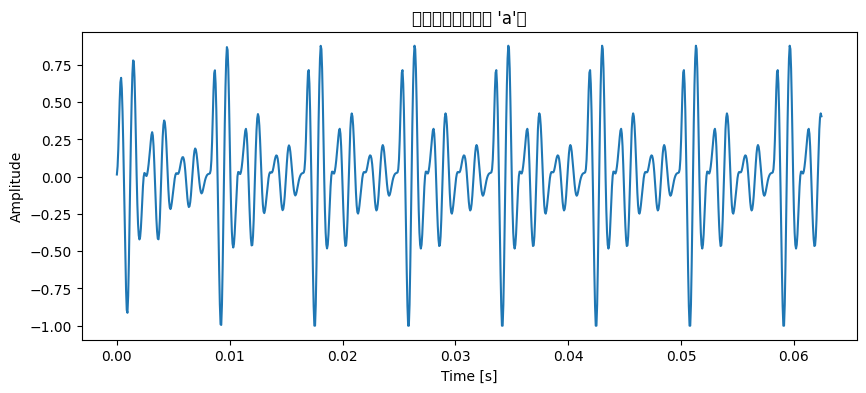

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter

# サンプリング周波数
fs = 16000
duration = 0.5  # 秒
t = np.linspace(0, duration, int(fs*duration), endpoint=False)

# 基本周波数（声の高さ）
f0 = 120  # Hz
excitation = np.zeros_like(t)
excitation[::int(fs/f0)] = 1.0
def formant_filter(signal, freq, bw, gain=1.0):
    """
    単一フォルマント用IIRフィルタ
    freq: フォルマント中心周波数 (Hz)
    bw: バンド幅 (Hz)
    gain: 強度（ゲイン）
    """
    r = np.exp(-np.pi * bw / fs)
    theta = 2 * np.pi * freq / fs
    a = [1, -2*r*np.cos(theta), r**2]
    b = [gain*(1-r)]
    return lfilter(b, a, signal)

# 母音 "a" のフォルマント例（男性話者）
formants = [
    {"freq": 730, "bw": 80, "gain": 1.5},   # F1
    {"freq": 1090,"bw": 90, "gain": 0.8},   # F2
    {"freq": 2440,"bw": 120,"gain": 2.0},   # F3
]

# 合成音作成
y = excitation.copy()
for f in formants:
    y = formant_filter(y, f["freq"], f["bw"], f["gain"])

# 正規化
y = y / np.max(np.abs(y))

# 波形表示
plt.figure(figsize=(10,4))
plt.plot(t[:1000], y[:1000])  # 最初の1000サンプル表示
plt.title("合成音波形（母音 'a'）")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.show()

# wav保存
from scipy.io.wavfile import write
write("formant_synthesis_a.wav", fs, (y * 32767).astype(np.int16))
